# **PHASE 1 — TẢI DATASET & EDA**

**Cell 1.1: Tải ISIC 2019 qua Kaggle**

In [ ]:
import torch
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Torch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
print("Mounted:", os.path.ismount('/content/drive'))
print("MyDrive:", os.listdir('/content/drive/MyDrive'))

Mounted: True
MyDrive: ['Colab Notebooks', 'Sách học.gdoc', 'Hướng Dẫn Luyện Thi Vstep - 1980Edu.gdoc', 'Sách gốc.gdoc', 'agmap_v1.0', 'Buoi3.drawio', 'skin_cancer']


In [ ]:
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive', force_remount=True)

# Verify ghi được
test = '/content/drive/MyDrive/.write_test'
try:
    open(test, 'w').write('x')
    os.remove(test)
    print("✓ Drive mới OK")
except Exception as e:
    raise RuntimeError(f"✗ Drive không ghi được: {e}")

print("Email:", !gcloud config list account --format "value(core.account)" 2>/dev/null || "N/A")

SyntaxError: invalid syntax (1329990517.py, line 16)

In [ ]:
!pip install timm grad-cam gradio --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
BASE = '/content/drive/MyDrive/skin_cancer'
os.makedirs(f'{BASE}/checkpoints', exist_ok=True)
os.makedirs(f'{BASE}/results', exist_ok=True)
os.makedirs(f'{BASE}/figures', exist_ok=True)
print(f"Đã tạo thư mục: {BASE}")

Đã tạo thư mục: /content/drive/MyDrive/skin_cancer


**Up file kaggle.json**

In [ ]:
from google.colab import files
files.upload()   # chọn file kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"thanhhoiphan","key":"98e958ce66bb6f6fc03ebbea62adc2d0"}'}

**Set up Kangle**

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

**Tải dataset**

In [ ]:
# Tải bản rút gọn 224×224 (~2GB) — khuyến nghị
!kaggle datasets download -d salviohexia/isic-2019-skin-lesion-images-for-classification -p /content/data/

Dataset URL: https://www.kaggle.com/datasets/salviohexia/isic-2019-skin-lesion-images-for-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 9.10G/9.10G [01:39<00:00, 98.6MB/s]



In [ ]:
!mkdir -p /content/data/isic2019
!unzip -q /content/data/isic-2019-skin-lesion-images-for-classification.zip -d /content/data/isic2019/
!ls /content/data/isic2019/

replace /content/data/isic2019/AK/ISIC_0024468.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

**Cell 1.2: Load metadata**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

DATA_DIR = '/content/data/isic2019'

# Tìm file metadata
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith('.csv'):
            print(os.path.join(root, f))

/content/data/isic2019/ISIC_2019_Training_Metadata.csv
/content/data/isic2019/ISIC_2019_Training_GroundTruth.csv


In [ ]:
META_PATH = f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv'
df = pd.read_csv(META_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

Shape: (25331, 10)
Columns: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
3  ISIC_0000003  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
4  ISIC_0000004  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0


**Cell 1.3: Chuyển sang label số**

label_name
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64


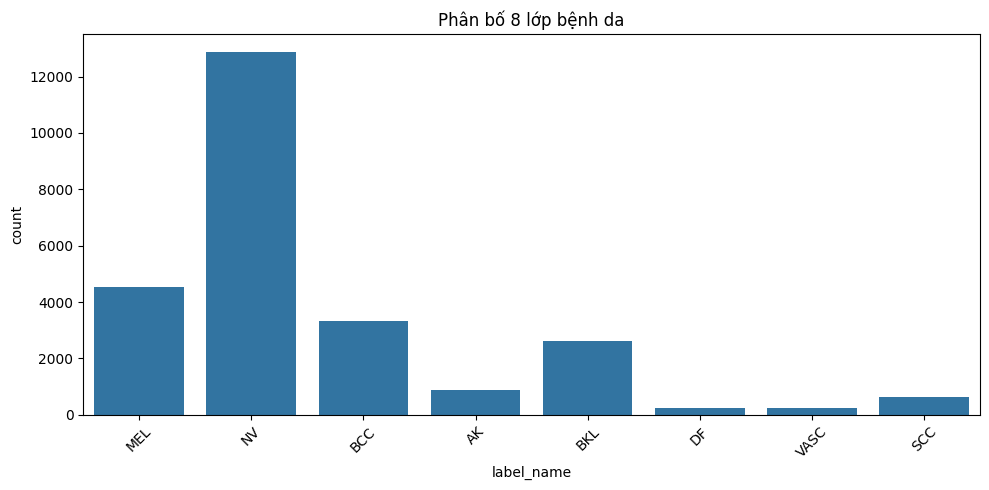

In [ ]:
# 8 lớp
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

# Tạo cột label (0-7)
df['label'] = df[CLASSES].values.argmax(axis=1)
df['label_name'] = df['label'].map(dict(enumerate(CLASSES)))

print(df['label_name'].value_counts())

# Vẽ phân bố
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label_name', order=CLASSES)
plt.title('Phân bố 8 lớp bệnh da')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/class_distribution.png', dpi=150)
plt.show()

**Cell 1.4: Tìm đường dẫn ảnh**

In [ ]:
import os

DATA_DIR = '/content/data/isic2019'
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

def clean_id(name):
    """Chuẩn hóa image_id: bỏ extension và _downsampled"""
    name = name.rsplit('.', 1)[0]           # bỏ .jpg/.png
    name = name.replace('_downsampled', '') # bỏ _downsampled
    return name

# Build lookup: clean_id → full path
img_lookup = {}
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            key = clean_id(fname)
            img_lookup[key] = os.path.join(cls_dir, fname)

print(f"Tổng ảnh trong lookup: {len(img_lookup)}")

# Gán path — cũng clean_id từ metadata
df['img_path'] = df['image'].apply(lambda x: img_lookup.get(clean_id(x)))

missing = df['img_path'].isna().sum()
print(f"Ảnh tìm thấy: {len(df) - missing}/{len(df)}")
print(f"Ảnh thiếu: {missing}")

if missing > 0:
    print("\n5 ảnh thiếu đầu tiên:")
    print(df[df['img_path'].isna()]['image'].head().tolist())

Tổng ảnh trong lookup: 25331
Ảnh tìm thấy: 25331/25331
Ảnh thiếu: 0


**Cell 1.5: Hiển thị ảnh mẫu**

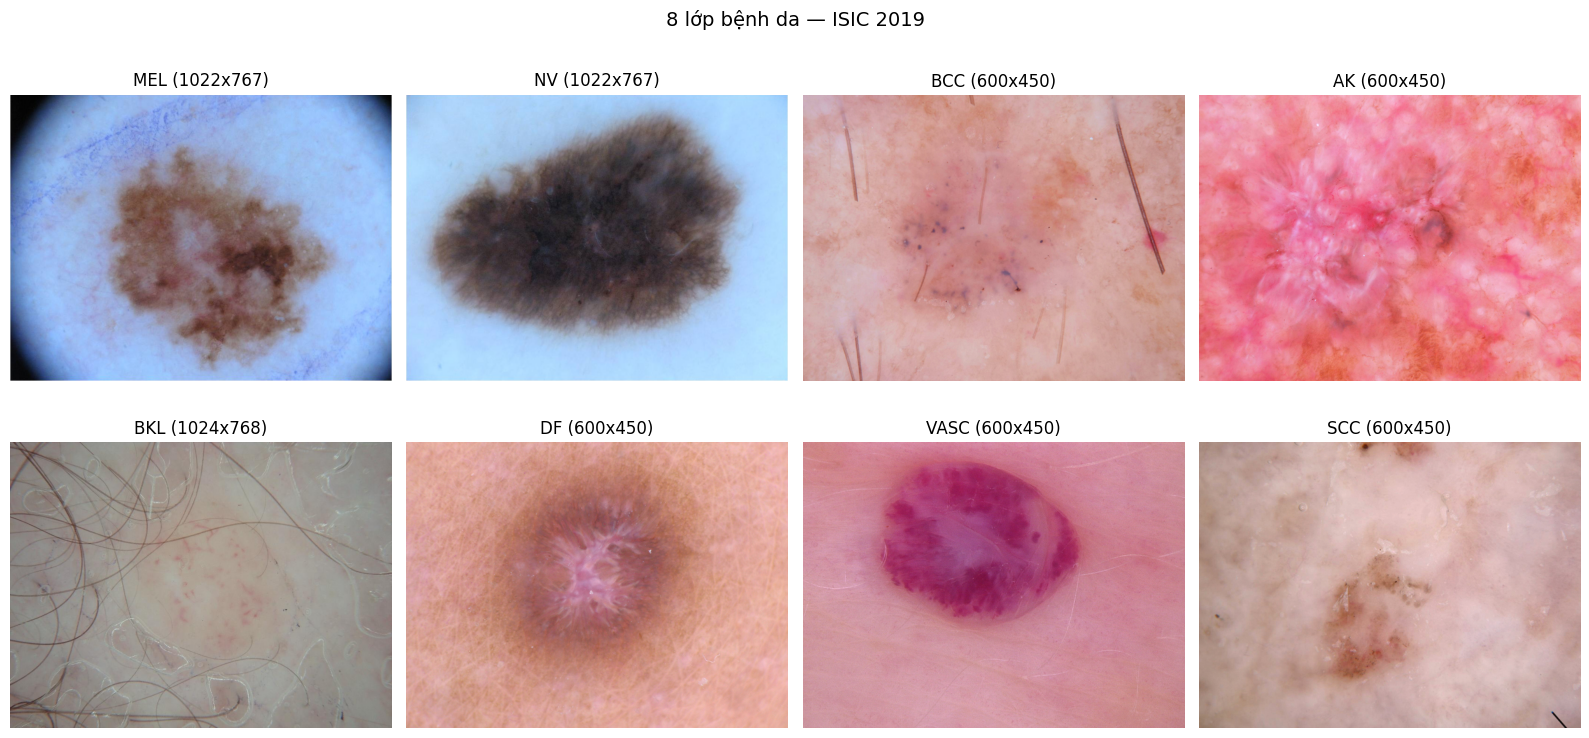

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, cls in zip(axes.flatten(), CLASSES):
    sample = df[df['label_name'] == cls].iloc[0]
    img = Image.open(sample['img_path'])
    ax.imshow(img)
    ax.set_title(f"{cls} ({img.size[0]}x{img.size[1]})")
    ax.axis('off')
plt.suptitle("8 lớp bệnh da — ISIC 2019", fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/figures/sample_images.png', dpi=150)
plt.show()

**Cell 1.6: Kiểm tra kích thước ảnh**

In [ ]:
import numpy as np

sizes = []
for p in df['img_path'].sample(200):
    try:
        img = Image.open(p)
        sizes.append(img.size)
    except:
        continue

sizes = np.array(sizes)
print(f"Đã kiểm tra: {len(sizes)} ảnh")
print(f"Width:  min={sizes[:,0].min()}, max={sizes[:,0].max()}, mean={sizes[:,0].mean():.0f}")
print(f"Height: min={sizes[:,1].min()}, max={sizes[:,1].max()}, mean={sizes[:,1].mean():.0f}")

Đã kiểm tra: 200 ảnh
Width:  min=600, max=1024, mean=862
Height: min=450, max=1024, mean=769


**Cell 1.7: Lưu dataframe**

In [ ]:
df.to_csv(f'{BASE}/isic2019_metadata.csv', index=False)
print(f"✓ Đã lưu metadata: {BASE}/isic2019_metadata.csv")

✓ Đã lưu metadata: /content/drive/MyDrive/skin_cancer/isic2019_metadata.csv


## **PHASE 2 — CHIA DỮ LIỆU & DATASET CLASS**

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image

# ===== SETUP =====
BASE = '/content/drive/MyDrive/skin_cancer'
os.makedirs(BASE, exist_ok=True)
os.makedirs(f'{BASE}/checkpoints', exist_ok=True)
os.makedirs(f'{BASE}/figures', exist_ok=True)
os.makedirs(f'{BASE}/results', exist_ok=True)

DATA_DIR = '/content/data/isic2019'
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

# ===== LOAD GROUNDTRUTH =====
gt = pd.read_csv(f'{DATA_DIR}/ISIC_2019_Training_GroundTruth.csv')
print("GroundTruth shape:", gt.shape)
print("Columns:", gt.columns.tolist())
print(gt.head(3))

# ===== TẠO LABEL =====
df = gt[['image'] + CLASSES].copy()
df['label'] = df[CLASSES].values.argmax(axis=1)
df['label_name'] = df['label'].map(dict(enumerate(CLASSES)))

print("\nPhân bố 8 lớp:")
print(df['label_name'].value_counts())

# ===== BUILD LOOKUP ẢNH =====
def clean_id(name):
    name = name.rsplit('.', 1)[0]
    name = name.replace('_downsampled', '')
    return name

img_lookup = {}
for cls in CLASSES:
    cls_dir = os.path.join(DATA_DIR, cls)
    if not os.path.exists(cls_dir):
        print(f"Không có folder: {cls_dir}")
        continue
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_lookup[clean_id(fname)] = os.path.join(cls_dir, fname)

print(f"\nTổng ảnh trong lookup: {len(img_lookup)}")

# ===== GÁN PATH =====
df['img_path'] = df['image'].apply(lambda x: img_lookup.get(clean_id(x)))
missing = df['img_path'].isna().sum()
print(f"Ảnh tìm thấy: {len(df) - missing}/{len(df)}")

if missing > 0:
    df = df.dropna(subset=['img_path']).reset_index(drop=True)
    print(f"Đã drop ảnh thiếu. Còn lại: {len(df)}")

# ===== LƯU METADATA =====
df.to_csv(f'{BASE}/isic2019_metadata.csv', index=False)
print(f"\n✓ Đã lưu: {BASE}/isic2019_metadata.csv")
print(f"  File tồn tại: {os.path.exists(f'{BASE}/isic2019_metadata.csv')}")

# ===== CHIA SPLITS =====
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['label'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['label'], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)}")
print(f"Val:   {len(val_df)}")
print(f"Test:  {len(test_df)}")

# Lưu
train_df.to_csv(f'{BASE}/train.csv', index=False)
val_df.to_csv(f'{BASE}/val.csv', index=False)
test_df.to_csv(f'{BASE}/test.csv', index=False)
print("✓ Đã lưu splits: train.csv, val.csv, test.csv")

# ===== TẠO BINARY LABEL =====
MALIGNANT = ['MEL', 'BCC', 'SCC', 'AK']

for d in [train_df, val_df, test_df]:
    d['binary_label'] = d['label_name'].apply(lambda x: 1 if x in MALIGNANT else 0)

print(f"\n=== Binary label distribution (train) ===")
print(train_df['binary_label'].value_counts())
print(f"Ung thư: {(train_df['binary_label']==1).mean()*100:.1f}%")
print(f"Lành:    {(train_df['binary_label']==0).mean()*100:.1f}%")

# Lưu lại splits với binary
train_df.to_csv(f'{BASE}/train.csv', index=False)
val_df.to_csv(f'{BASE}/val.csv', index=False)
test_df.to_csv(f'{BASE}/test.csv', index=False)

print("\n" + "="*50)
print("HOÀN TẤT PHASE 1 + 2")
print("="*50)
print(f"Metadata: {BASE}/isic2019_metadata.csv")
print(f"Train: {BASE}/train.csv ({len(train_df)} ảnh)")
print(f"Val:   {BASE}/val.csv ({len(val_df)} ảnh)")
print(f"Test:  {BASE}/test.csv ({len(test_df)} ảnh)")

GroundTruth shape: (25331, 10)
Columns: ['image', 'MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC', 'UNK']
          image  MEL   NV  BCC   AK  BKL   DF  VASC  SCC  UNK
0  ISIC_0000000  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
1  ISIC_0000001  0.0  1.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0
2  ISIC_0000002  1.0  0.0  0.0  0.0  0.0  0.0   0.0  0.0  0.0

Phân bố 8 lớp:
label_name
NV      12875
MEL      4522
BCC      3323
BKL      2624
AK        867
SCC       628
VASC      253
DF        239
Name: count, dtype: int64

Tổng ảnh trong lookup: 25331
Ảnh tìm thấy: 25331/25331

✓ Đã lưu: /content/drive/MyDrive/skin_cancer/isic2019_metadata.csv
  File tồn tại: True

Train: 17731
Val:   3800
Test:  3800
✓ Đã lưu splits: train.csv, val.csv, test.csv

=== Binary label distribution (train) ===
binary_label
0    11193
1     6538
Name: count, dtype: int64
Ung thư: 36.9%
Lành:    63.1%

HOÀN TẤT PHASE 1 + 2
Metadata: /content/drive/MyDrive/skin_cancer/isic2019_metadata.csv
Train: /content/drive/My

In [ ]:
import os
BASE = '/content/drive/MyDrive/skin_cancer'
for f in ['train.csv','val.csv','test.csv','isic2019_metadata.csv']:
    p = f'{BASE}/{f}'
    print(('✓' if os.path.exists(p) else '✗'), f)

✓ train.csv
✓ val.csv
✓ test.csv
✓ isic2019_metadata.csv


# **PHASE 3 — TRAIN BINARY VỚI EFFICIENTNET-B0**

**Cell 3.1: Class weights**

In [ ]:
import torch
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

BASE = '/content/drive/MyDrive/skin_cancer'
CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

# Multi-class weights
cw_mc = compute_class_weight('balanced', classes=np.arange(8), y=train_df['label'].values)
cw_mc = torch.tensor(cw_mc, dtype=torch.float32)
print("Class weights (multi-class):")
for cls, w in zip(CLASSES, cw_mc):
    print(f"  {cls}: {w:.3f}")

# Binary weights
cw_bin = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['binary_label'].values)
cw_bin = torch.tensor(cw_bin, dtype=torch.float32)
print(f"\nClass weights (binary):")
print(f"  Lành:    {cw_bin[0]:.3f}")
print(f"  Ung thư: {cw_bin[1]:.3f}")

torch.save(cw_mc, f'{BASE}/class_weights_mc.pt')
torch.save(cw_bin, f'{BASE}/class_weights_bin.pt')
print("\n✓ Đã lưu class weights")

Class weights (multi-class):
  MEL: 0.700
  NV: 0.246
  BCC: 0.953
  AK: 3.651
  BKL: 1.207
  DF: 13.272
  VASC: 12.522
  SCC: 5.037

Class weights (binary):
  Lành:    0.792
  Ung thư: 1.356

✓ Đã lưu class weights


**Cell 3.2: Dataset class + transforms**

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class SkinCancerDataset(Dataset):
    def __init__(self, df, transform=None, label_col='label'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = int(row[self.label_col])
        return img, label


def get_transforms(split='train', img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

# DataLoaders
BATCH_SIZE = 32
IMG_SIZE = 224

train_ds = SkinCancerDataset(train_df, get_transforms('train', IMG_SIZE), 'binary_label')
val_ds   = SkinCancerDataset(val_df,   get_transforms('val', IMG_SIZE),   'binary_label')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Test batch
imgs, labels = next(iter(train_loader))
print("Batch images:", imgs.shape)   # (32, 3, 224, 224)
print("Batch labels:", labels.shape)
print("Label distribution:", labels.bincount().tolist())

Batch images: torch.Size([32, 3, 224, 224])
Batch labels: torch.Size([32])
Label distribution: [22, 10]


**Cell 3.3: Model EfficientNet-B0**

In [ ]:
import timm
import torch.nn as nn

class SkinCancerEfficientNet(nn.Module):
    def __init__(self, backbone='efficientnet_b0', num_classes=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)


DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

model = SkinCancerEfficientNet(num_classes=2).to(DEVICE)
print("Total params:", f"{sum(p.numel() for p in model.parameters()):,}")

# Test
x = torch.randn(2, 3, 224, 224).to(DEVICE)
y = model(x)
print("Output shape:", y.shape)   # (2, 2)

Device: cuda


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Total params: 4,335,998
Output shape: torch.Size([2, 2])


**Cell 3.4: Train function + Evaluate function**

In [ ]:
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)[:, 1]   # xác suất ung thư
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = (all_probs > 0.5).astype(int)

    return {
        'loss': total_loss / len(loader.dataset),
        'acc': accuracy_score(all_labels, preds),
        'precision': precision_score(all_labels, preds, zero_division=0),
        'recall': recall_score(all_labels, preds, zero_division=0),
        'f1': f1_score(all_labels, preds, zero_division=0),
        'auc': roc_auc_score(all_labels, all_probs),
    }, all_probs, all_labels

**Cell 3.5: Train binary**


In [ ]:
# Config
EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-4

# Class weights cho binary
cw_bin_device = cw_bin.to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_bin_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Train
best_auc = 0
history = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_metrics, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    history.append({'epoch': epoch+1, 'train_loss': train_loss, **val_metrics})

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | "
          f"train={train_loss:.4f} | "
          f"val_loss={val_metrics['loss']:.4f} | "
          f"acc={val_metrics['acc']:.4f} | "
          f"auc={val_metrics['auc']:.4f} | "
          f"f1={val_metrics['f1']:.4f} | "
          f"recall={val_metrics['recall']:.4f}")

    if val_metrics['auc'] > best_auc:
        best_auc = val_metrics['auc']
        torch.save(model.state_dict(), f'{BASE}/checkpoints/best_binary.pth')
        print(f"  ✓ Saved (AUC={val_metrics['auc']:.4f})")

print(f"\nBest val AUC: {best_auc:.4f}")

# Lưu history
import pandas as pd
pd.DataFrame(history).to_csv(f'{BASE}/results/binary_history.csv', index=False)

Epoch  1/15 | train=0.4986 | val_loss=0.4597 | acc=0.8066 | auc=0.8778 | f1=0.7277 | recall=0.7014
  ✓ Saved (AUC=0.8778)


Epoch  2/15 | train=0.4537 | val_loss=0.4344 | acc=0.8050 | auc=0.8825 | f1=0.7324 | recall=0.7243
  ✓ Saved (AUC=0.8825)


Epoch  3/15 | train=0.4399 | val_loss=0.4163 | acc=0.8134 | auc=0.8921 | f1=0.7581 | recall=0.7936
  ✓ Saved (AUC=0.8921)


Epoch  4/15 | train=0.4275 | val_loss=0.3880 | acc=0.8179 | auc=0.9093 | f1=0.7739 | recall=0.8457
  ✓ Saved (AUC=0.9093)


Epoch  5/15 | train=0.4006 | val_loss=0.3927 | acc=0.8263 | auc=0.9067 | f1=0.7746 | recall=0.8100


...

Epoch 11/15 | train=0.2686 | val_loss=0.3414 | acc=0.8674 | auc=0.9378 | f1=0.8206 | recall=0.8236
  ✓ Saved (AUC=0.9378)


Epoch 12/15 | train=0.2423 | val_loss=0.3417 | acc=0.8663 | auc=0.9409 | f1=0.8254 | recall=0.8579
  ✓ Saved (AUC=0.9409)


Epoch 13/15 | train=0.2210 | val_loss=0.3368 | acc=0.8671 | auc=0.9411 | f1=0.8202 | recall=0.8229
  ✓ Saved (AUC=0.9411)


Epoch 14/15 | train=0.2045 | val_loss=0.3530 | acc=0.8682 | auc=0.9417 | f1=0.8216 | recall=0.8243
  ✓ Saved (AUC=0.9417)


Epoch 15/15 | train=0.1960 | val_loss=0.3597 | acc=0.8674 | auc=0.9419 | f1=0.8211 | recall=0.8264
  ✓ Saved (AUC=0.9419)

Best val AUC: 0.9419


# **PHASE 4 — ĐÁNH GIÁ TEST SET**

**Cell 4.1: Setup + Load best model**

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from PIL import Image
from torchvision import transforms
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import timm

BASE = '/content/drive/MyDrive/skin_cancer'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load splits
train_df = pd.read_csv(f'{BASE}/train.csv')
val_df   = pd.read_csv(f'{BASE}/val.csv')
test_df  = pd.read_csv(f'{BASE}/test.csv')
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Dataset class
class SkinCancerDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None, label_col='label'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row[self.label_col])

def get_transforms(split='val', img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])

# Model
class SkinCancerEfficientNet(nn.Module):
    def __init__(self, backbone='efficientnet_b0', num_classes=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

# Load best checkpoint
model = SkinCancerEfficientNet(num_classes=2).to(DEVICE)
model.load_state_dict(torch.load(f'{BASE}/checkpoints/best_binary.pth', map_location=DEVICE))
model.eval()
print("✓ Loaded best model")

ModuleNotFoundError: No module named 'timm'

**Cell 4.2: Evaluate test set**

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = 224

test_ds = SkinCancerDataset(test_df, get_transforms('val', IMG_SIZE), 'binary_label')
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

@torch.no_grad()
def predict(model, loader):
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1]
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

test_probs, test_labels = predict(model, test_loader)
test_preds = (test_probs > 0.5).astype(int)

# Metrics
print("=" * 50)
print("TEST SET METRICS")
print("=" * 50)
print(f"Accuracy:  {accuracy_score(test_labels, test_preds):.4f}")
print(f"Precision: {precision_score(test_labels, test_preds):.4f}")
print(f"Recall:    {recall_score(test_labels, test_preds):.4f}")
print(f"F1:        {f1_score(test_labels, test_preds):.4f}")
print(f"AUC-ROC:   {roc_auc_score(test_labels, test_probs):.4f}")
print("=" * 50)

TEST SET METRICS
Accuracy:  0.8626
Precision: 0.8056
Recall:    0.8274
F1:        0.8163
AUC-ROC:   0.9366


**Cell 4.3: Confusion matrix + ROC**

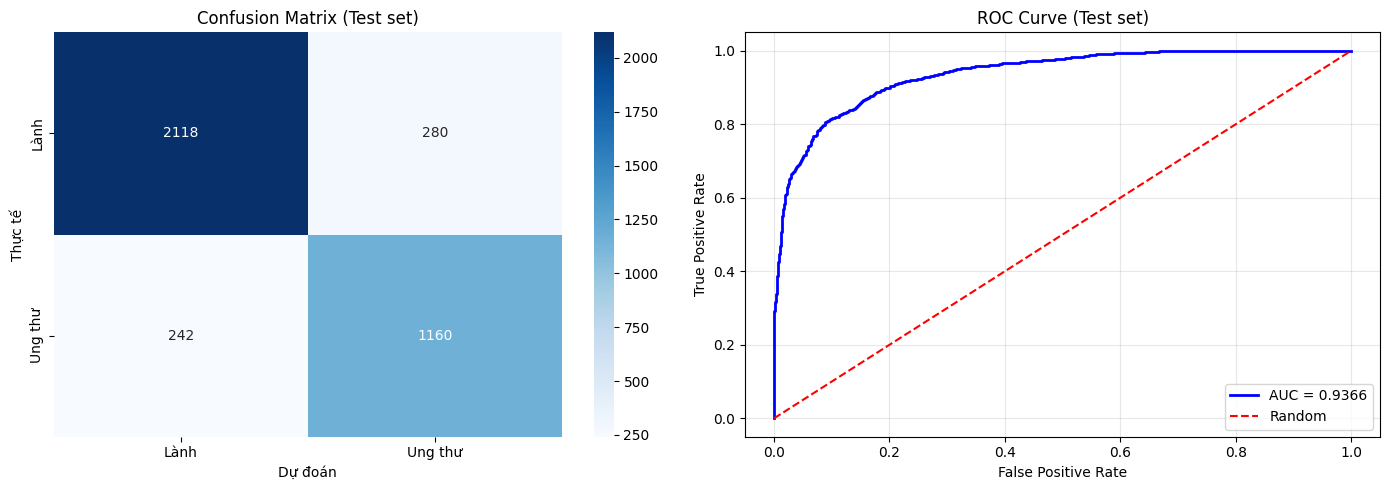

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Lành', 'Ung thư'],
            yticklabels=['Lành', 'Ung thư'], ax=axes[0])
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')
axes[0].set_title('Confusion Matrix (Test set)')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
auc = roc_auc_score(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', label=f'AUC = {auc:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'r--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Test set)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/binary_test_evaluation.png', dpi=150)
plt.show()

**Cell 4.4: Classification report chi tiết**

In [ ]:
print(classification_report(test_labels, test_preds,
                             target_names=['Lành', 'Ung thư'],
                             digits=4))

# Phân tích lỗi
tn, fp, fn, tp = cm.ravel()
print(f"\nChi tiết:")
print(f"  True Negative  (đoán lành, thực lành):    {tn}")
print(f"  False Positive (đoán ung thư, thực lành): {fp}")
print(f"  False Negative (đoán lành, thực ung thư): {fn}  ← NGUY HIỂM")
print(f"  True Positive  (đoán ung thư, thực ung thư): {tp}")
print(f"\nTỷ lệ bỏ sót ung thư: {fn/(fn+tp)*100:.1f}%")
print(f"Tỷ lệ báo động giả:   {fp/(fp+tn)*100:.1f}%")

              precision    recall  f1-score   support

        Lành     0.8975    0.8832    0.8903      2398
     Ung thư     0.8056    0.8274    0.8163      1402

    accuracy                         0.8626      3800
   macro avg     0.8515    0.8553    0.8533      3800
weighted avg     0.8636    0.8626    0.8630      3800


Chi tiết:
  True Negative  (đoán lành, thực lành):    2118
  False Positive (đoán ung thư, thực lành): 280
  False Negative (đoán lành, thực ung thư): 242  ← NGUY HIỂM
  True Positive  (đoán ung thư, thực ung thư): 1160

Tỷ lệ bỏ sót ung thư: 17.3%
Tỷ lệ báo động giả:   11.7%


**Cell 4.5: Lưu kết quả**

In [ ]:
# Lưu predictions
results_df = test_df[['image', 'label_name', 'binary_label', 'img_path']].copy()
results_df['prob_malignant'] = test_probs
results_df['pred_binary'] = test_preds
results_df['correct'] = (results_df['binary_label'] == results_df['pred_binary']).astype(int)
results_df.to_csv(f'{BASE}/results/binary_test_predictions.csv', index=False)
print(f"✓ Đã lưu predictions: {BASE}/results/binary_test_predictions.csv")

# Top false negatives (bỏ sót ung thư)
fn_df = results_df[(results_df['binary_label'] == 1) & (results_df['pred_binary'] == 0)]
fn_df = fn_df.sort_values('prob_malignant').head(10)
print(f"\n10 ca bỏ sót ung thư (prob thấp nhất):")
print(fn_df[['image', 'label_name', 'prob_malignant']])

✓ Đã lưu predictions: /content/drive/MyDrive/skin_cancer/results/binary_test_predictions.csv

10 ca bỏ sót ung thư (prob thấp nhất):
                         image label_name  prob_malignant
1815  ISIC_0012425_downsampled        MEL        0.000132
987               ISIC_0055359        MEL        0.000908
1764              ISIC_0059421        MEL        0.001058
1870  ISIC_0015082_downsampled        MEL        0.001213
94                ISIC_0000313        MEL        0.001423
1907  ISIC_0013277_downsampled        MEL        0.001443
1007              ISIC_0058220        BCC        0.001693
3141              ISIC_0031957        MEL        0.002203
2830  ISIC_0013365_downsampled        MEL        0.002249
1566              ISIC_0011169        MEL        0.002766


In [ ]:
import os
BASE = '/content/drive/MyDrive/skin_cancer'
for f in ['checkpoints/best_binary.pth',
          'results/binary_history.csv',
          'results/binary_test_predictions.csv',
          'figures/binary_test_evaluation.png']:
    p = f'{BASE}/{f}'
    print(('✓' if os.path.exists(p) else '✗'), f,
          f"({os.path.getsize(p)/1e6:.1f}MB)" if os.path.exists(p) else "")

✓ checkpoints/best_binary.pth (17.6MB)
✓ results/binary_history.csv (0.0MB)
✓ results/binary_test_predictions.csv (0.3MB)
✓ figures/binary_test_evaluation.png (0.1MB)


# **PHASE 5 — TRAIN MULTI-CLASS 8 LỚP**

**Cell 5.1: Setup multi-class Dataset + DataLoader**

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = 224
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Multi-class dataset (label 0-7)
train_ds_mc = SkinCancerDataset(train_df, get_transforms('train', IMG_SIZE), 'label')
val_ds_mc   = SkinCancerDataset(val_df,   get_transforms('val', IMG_SIZE),   'label')
test_ds_mc  = SkinCancerDataset(test_df,  get_transforms('val', IMG_SIZE),   'label')

train_loader_mc = DataLoader(train_ds_mc, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader_mc   = DataLoader(val_ds_mc,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader_mc  = DataLoader(test_ds_mc,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader_mc)}")
print(f"Val batches:   {len(val_loader_mc)}")
print(f"Test batches:  {len(test_loader_mc)}")

Train batches: 555
Val batches:   119
Test batches:  119


**Cell 5.2: Model multi-class + Class weights**

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
EPOCHS_MC = 20

# Cải tiến 1: cap class weights ở 5.0 (tránh bóp méo lớp hiếm)
cw_mc = torch.tensor(
    compute_class_weight('balanced', classes=np.arange(8), y=train_df['label'].values),
    dtype=torch.float32
)
cw_mc_capped = torch.tensor(np.clip(cw_mc.numpy(), None, 5.0), dtype=torch.float32)
print("Capped class weights:")
for cls, w in zip(CLASSES, cw_mc_capped):
    print(f"  {cls}: {w:.3f}")

# Cải tiến 2: dropout cao hơn + pretrained=True
model_mc = SkinCancerEfficientNet(
    backbone='efficientnet_b0', num_classes=8,
    dropout=0.4
).to(DEVICE)
print("Params:", f"{sum(p.numel() for p in model_mc.parameters()):,}")

# Cải tiến 3: label smoothing
criterion_mc = nn.CrossEntropyLoss(
    weight=cw_mc_capped.to(DEVICE),
    label_smoothing=0.1
)

# Cải tiến 4: differential LR (backbone 1e-4, head 1e-3) + weight decay 5e-4
optimizer_mc = torch.optim.AdamW([
    {'params': list(model_mc.backbone.parameters()), 'lr': 1e-4},
    {'params': list(model_mc.head.parameters()),     'lr': 1e-3},
], weight_decay=5e-4)

scheduler_mc = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_mc, T_max=EPOCHS_MC, eta_min=1e-6
)

Capped class weights:
  MEL: 0.700
  NV: 0.246
  BCC: 0.953
  AK: 3.651
  BKL: 1.207
  DF: 5.000
  VASC: 5.000
  SCC: 5.000
Params: 4,337,540


**Cell 5.3: Train + evaluate multi-class**

In [ ]:
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, f1_score,
                              balanced_accuracy_score, cohen_kappa_score)


def train_one_epoch_mc(model, loader, opt, crit):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        logits = model(imgs)
        loss = crit(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_mc(model, loader, crit):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += crit(logits, labels).item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    return {
        'loss': total_loss / len(loader.dataset),
        'acc': accuracy_score(all_labels, preds),
        'balanced_acc': balanced_accuracy_score(all_labels, preds),
        'f1_macro': f1_score(all_labels, preds, average='macro', zero_division=0),
        'kappa': cohen_kappa_score(all_labels, preds),
    }, all_probs, all_labels


best_bal_acc = 0
patience = 5
no_improve = 0
history_mc = []

for epoch in range(EPOCHS_MC):
    train_loss = train_one_epoch_mc(model_mc, train_loader_mc, optimizer_mc, criterion_mc)
    val_metrics, _, _ = evaluate_mc(model_mc, val_loader_mc, criterion_mc)
    scheduler_mc.step()

    history_mc.append({'epoch': epoch+1, 'train_loss': train_loss, **val_metrics})

    print(f"Epoch {epoch+1:2d}/{EPOCHS_MC} | "
          f"train={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
          f"acc={val_metrics['acc']:.4f} | bal_acc={val_metrics['balanced_acc']:.4f} | "
          f"f1={val_metrics['f1_macro']:.4f} | kappa={val_metrics['kappa']:.4f}")

    if val_metrics['balanced_acc'] > best_bal_acc:
        best_bal_acc = val_metrics['balanced_acc']
        no_improve = 0
        torch.save(model_mc.state_dict(), f'{BASE}/checkpoints/best_multiclass.pth')
        print(f"  ✓ Saved (Bal Acc={best_bal_acc:.4f})")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{patience})")
        if no_improve >= patience:
            print(f"Early stopping tại epoch {epoch+1}")
            break

    pd.DataFrame(history_mc).to_csv(f'{BASE}/results/multiclass_history.csv', index=False)

print(f"\nBest balanced accuracy: {best_bal_acc:.4f}")

Epoch  1/20 | train=2.1363 | val_loss=1.9001 | acc=0.6518 | bal_acc=0.6512 | f1=0.4961 | kappa=0.5258
  ✓ Saved (Bal Acc=0.6512)


Epoch  2/20 | train=1.7927 | val_loss=1.7848 | acc=0.7471 | bal_acc=0.7247 | f1=0.6403 | kappa=0.6428
  ✓ Saved (Bal Acc=0.7247)


Epoch  3/20 | train=1.5966 | val_loss=1.7629 | acc=0.7466 | bal_acc=0.7292 | f1=0.6443 | kappa=0.6435
  ✓ Saved (Bal Acc=0.7292)


Epoch  4/20 | train=1.4524 | val_loss=1.7748 | acc=0.7839 | bal_acc=0.7238 | f1=0.6812 | kappa=0.6877
  (no improve 1/5)


Epoch  5/20 | train=1.3715 | val_loss=1.7400 | acc=0.7858 | bal_acc=0.7415 | f1=0.6987 | kappa=0.6922
  ✓ Saved (Bal Acc=0.7415)


...

Epoch 10/20 | train=1.2122 | val_loss=1.7337 | acc=0.8289 | bal_acc=0.7523 | f1=0.7529 | kappa=0.7473
  (no improve 1/5)


Epoch 11/20 | train=1.2005 | val_loss=1.6895 | acc=0.8218 | bal_acc=0.7819 | f1=0.7505 | kappa=0.7391
  ✓ Saved (Bal Acc=0.7819)


Epoch 12/20 | train=1.1895 | val_loss=1.7011 | acc=0.8237 | bal_acc=0.7768 | f1=0.7466 | kappa=0.7412
  (no improve 1/5)


Epoch 13/20 | train=1.1880 | val_loss=1.7215 | acc=0.8245 | bal_acc=0.7633 | f1=0.7497 | kappa=0.7388
  (no improve 2/5)


Train:   9%|▉         | 52/555 [00:24<03:04,  2.73it/s]

**Cell 5.4: Test Evaluation (Multi-class)**


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu
BASE:   D:\DoAnTriTueNhanTao\skin_cancer
Data:   D:\DoAnTriTueNhanTao\data\isic2019

Test set: 3800 ảnh
Tất cả ảnh đều tồn tại.

Loading checkpoint: D:\DoAnTriTueNhanTao\skin_cancer/checkpoints/best_multiclass.pth
Model loaded OK.
Test batches: 119

 ĐANG ĐÁNH GIÁ TEST SET (MULTI-CLASS)


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  loss          : 1.0651
  acc           : 0.8163
  balanced_acc  : 0.7815
  f1_macro      : 0.7547
  kappa         : 0.7305

              precision    recall  f1-score   support

         MEL     0.7610    0.6892    0.7233       679
          NV     0.8888    0.8897    0.8892      1931
         BCC     0.8201    0.8497    0.8346       499
          AK     0.5689    0.7308    0.6397       130
         BKL     0.6977    0.7048    0.7013       393
          DF     0.7209    0.8611    0.7848        36
        VASC     0.7872    0.9737    0.8706        38
         SCC     0.6420    0.5532    0.5943        94

    accuracy                         0.8163      3800
   macro avg     0.7358    0.7815    0.7547      3800
weighted avg     0.8175    0.8163    0.8160      3800

Đã lưu predictions: D:\DoAnTriTueNhanTao\skin_cancer/results/multiclass_test_predictions.csv


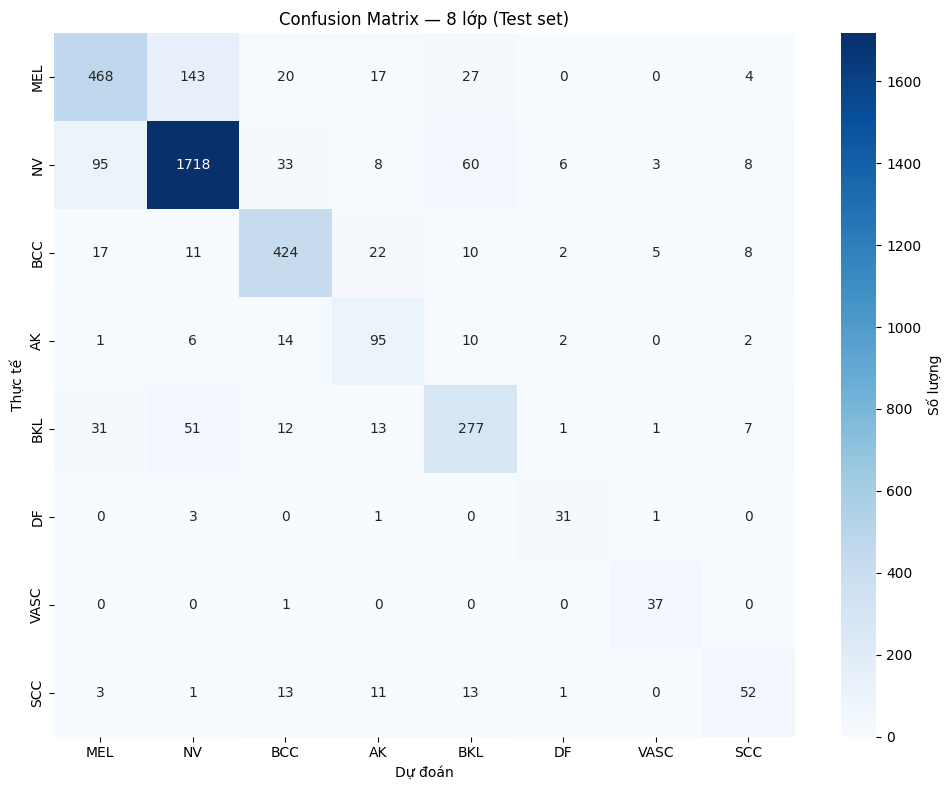

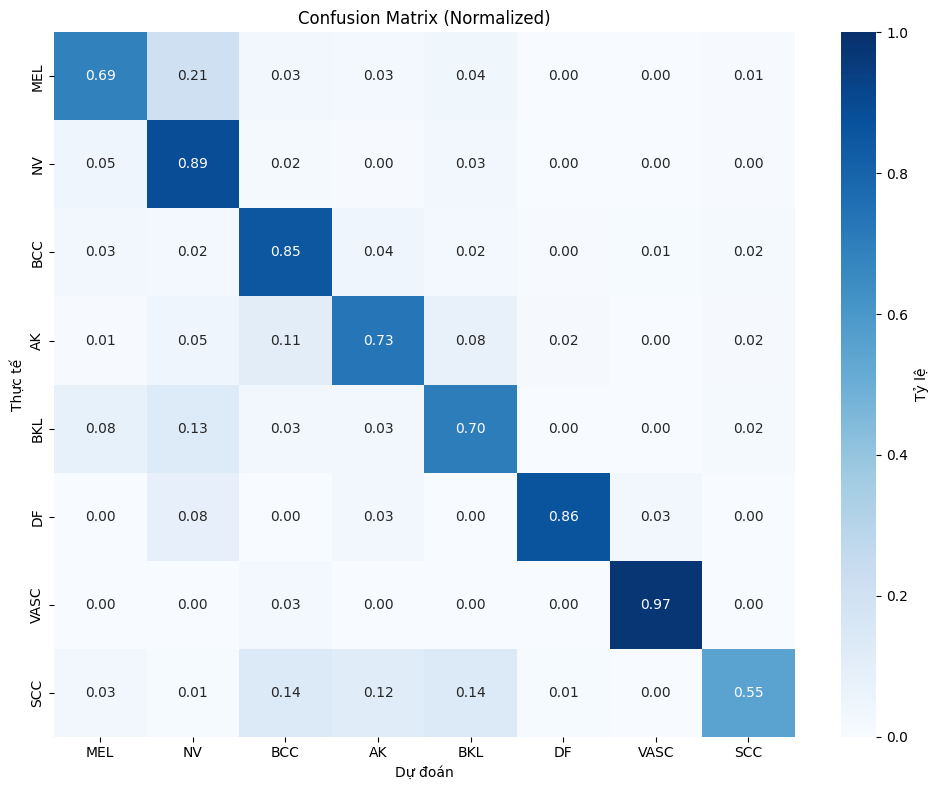


 HOÀN TẤT — 3 file đã lưu:
  ✓ results/multiclass_test_predictions.csv                 659.1KB
  ✓ figures/multiclass_confusion_matrix.png                 75.1KB
  ✓ figures/multiclass_confusion_matrix_norm.png            91.3KB


In [4]:
# ============================================================
# CELL 5.4 STANDALONE - Multi-class Test Evaluation
# Chạy độc lập, không cần chạy Cell 5.1-5.3
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import timm
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              balanced_accuracy_score, cohen_kappa_score)

# ============================================================
# 1. CONFIG — SỬA ĐƯỜNG DẪN CHO KHỚP MÁY BẠN
# ============================================================
BASE = r'D:\DoAnTriTueNhanTao\skin_cancer'
LOCAL_DATA_DIR = r'D:\DoAnTriTueNhanTao\data\isic2019'
# Nếu ảnh vẫn đang ở path Colab, đặt OLD_PATH_PREFIX = '/content/data/isic2019'
# Nếu ảnh đã ở local, để OLD_PATH_PREFIX = None
OLD_PATH_PREFIX = '/content/data/isic2019'

CLASSES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
IMG_SIZE = 224
BATCH_SIZE = 32
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Device: {DEVICE}")
print(f"BASE:   {BASE}")
print(f"Data:   {LOCAL_DATA_DIR}")

# Tạo folder nếu chưa có
os.makedirs(f'{BASE}/results', exist_ok=True)
os.makedirs(f'{BASE}/figures', exist_ok=True)

# ============================================================
# 2. LOAD TEST CSV & FIX PATHS
# ============================================================
test_df = pd.read_csv(f'{BASE}/test.csv')
print(f"\nTest set: {len(test_df)} ảnh")

# Sửa path từ Colab → local (nếu cần)
if OLD_PATH_PREFIX and 'img_path' in test_df.columns:
    mask = test_df['img_path'].str.startswith(OLD_PATH_PREFIX, na=False)
    n_fix = mask.sum()
    if n_fix > 0:
        test_df['img_path'] = test_df['img_path'].str.replace(
            OLD_PATH_PREFIX, LOCAL_DATA_DIR, regex=False)
        print(f"Đã sửa {n_fix} img_path từ Colab → local")

# Verify ảnh tồn tại
missing = (~test_df['img_path'].apply(os.path.exists)).sum()
if missing > 0:
    print(f"[CẢNH BÁO] {missing} ảnh không tìm thấy!")
    print("3 ví dụ:", test_df[~test_df['img_path'].apply(os.path.exists)]
                            ['img_path'].head(3).tolist())
else:
    print("Tất cả ảnh đều tồn tại.")

# ============================================================
# 3. DATASET + TRANSFORMS
# ============================================================
class SkinCancerDataset(Dataset):
    def __init__(self, df, transform=None, label_col='label'):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row[self.label_col])


def get_val_transform(img_size=224):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])


# ============================================================
# 4. MODEL DEFINITION (giống hệt lúc train)
# ============================================================
class SkinCancerEfficientNet(nn.Module):
    def __init__(self, backbone='efficientnet_b0', num_classes=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(backbone, pretrained=False, num_classes=0)
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


# ============================================================
# 5. LOAD BEST CHECKPOINT
# ============================================================
CKPT = f'{BASE}/checkpoints/best_multiclass.pth'
if not os.path.exists(CKPT):
    raise FileNotFoundError(f"Không tìm thấy checkpoint: {CKPT}")

print(f"\nLoading checkpoint: {CKPT}")
model_mc = SkinCancerEfficientNet(backbone='efficientnet_b0',
                                   num_classes=8,
                                   dropout=0.4).to(DEVICE)
model_mc.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model_mc.eval()
print("Model loaded OK.")

# ============================================================
# 6. CRITERION + LOADER
# ============================================================
criterion_mc = nn.CrossEntropyLoss()   # không cần class weights khi eval

test_ds_mc = SkinCancerDataset(test_df, get_val_transform(IMG_SIZE), 'label')
test_loader_mc = DataLoader(test_ds_mc, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0, pin_memory=True)
print(f"Test batches: {len(test_loader_mc)}")

# ============================================================
# 7. EVALUATE FUNCTION
# ============================================================
@torch.no_grad()
def evaluate_mc(model, loader, criterion):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0.0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += criterion(logits, labels).item() * imgs.size(0)

        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)

    return {
        'loss':         total_loss / len(loader.dataset),
        'acc':          accuracy_score(all_labels, preds),
        'balanced_acc': balanced_accuracy_score(all_labels, preds),
        'f1_macro':     f1_score(all_labels, preds, average='macro', zero_division=0),
        'kappa':        cohen_kappa_score(all_labels, preds),
    }, all_probs, all_labels


# ============================================================
# 8. RUN EVALUATION
# ============================================================
print("\n" + "=" * 55)
print(" ĐANG ĐÁNH GIÁ TEST SET (MULTI-CLASS)")
print("=" * 55)

test_metrics, test_probs_mc, test_labels_mc = evaluate_mc(
    model_mc, test_loader_mc, criterion_mc)

for k, v in test_metrics.items():
    print(f"  {k:14s}: {v:.4f}")

preds_mc = test_probs_mc.argmax(axis=1)
print("\n" + classification_report(test_labels_mc, preds_mc,
                                    target_names=CLASSES, digits=4))

# ============================================================
# 9. LƯU PREDICTIONS CSV
# ============================================================
res_mc = test_df[['image', 'label_name', 'label', 'img_path']].copy()
res_mc['pred_label'] = preds_mc
res_mc['pred_label_name'] = res_mc['pred_label'].map(dict(enumerate(CLASSES)))
for i, cls in enumerate(CLASSES):
    res_mc[f'prob_{cls}'] = test_probs_mc[:, i]

preds_path = f'{BASE}/results/multiclass_test_predictions.csv'
res_mc.to_csv(preds_path, index=False)
print(f"Đã lưu predictions: {preds_path}")

# ============================================================
# 10. CONFUSION MATRIX - RAW
# ============================================================
cm_mc = confusion_matrix(test_labels_mc, preds_mc)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mc, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar_kws={'label': 'Số lượng'})
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix — 8 lớp (Test set)')
plt.tight_layout()
plt.savefig(f'{BASE}/figures/multiclass_confusion_matrix.png',
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================
# 11. CONFUSION MATRIX - NORMALIZED
# ============================================================
cm_norm = cm_mc.astype('float') / cm_mc.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            vmin=0, vmax=1, cbar_kws={'label': 'Tỷ lệ'})
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(f'{BASE}/figures/multiclass_confusion_matrix_norm.png',
            dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# ============================================================
# 12. SUMMARY
# ============================================================
print("\n" + "=" * 55)
print(" HOÀN TẤT — 3 file đã lưu:")
print("=" * 55)
for f in ['results/multiclass_test_predictions.csv',
          'figures/multiclass_confusion_matrix.png',
          'figures/multiclass_confusion_matrix_norm.png']:
    p = f'{BASE}/{f}'
    ok = '✓' if os.path.exists(p) else '✗'
    size = f"{os.path.getsize(p)/1e3:.1f}KB" if os.path.exists(p) else "-"
    print(f"  {ok} {f:55s} {size}")

In [ ]:
import os
import pandas as pd
BASE = '/content/drive/MyDrive/skin_cancer'

# Kiểm tra checkpoint & history
files = ['checkpoints/best_multiclass.pth', 'results/multiclass_history.csv']
for f in files:
    p = f'{BASE}/{f}'
    print(('✓' if os.path.exists(p) else '✗'), f,
          f"({os.path.getsize(p)/1e6:.2f}MB)" if os.path.exists(p) else "")

# Xem đã train tới epoch nào
if os.path.exists(f'{BASE}/results/multiclass_history.csv'):
    hist = pd.read_csv(f'{BASE}/results/multiclass_history.csv')
    print(f"\nĐã train: {len(hist)} epoch")
    print(f"Best Bal Acc: {hist['balanced_acc'].max():.4f} (epoch {hist.loc[hist['balanced_acc'].idxmax(), 'epoch']:.0f})")
    print("\n5 epoch cuối:")
    print(hist.tail().to_string(index=False))

✓ checkpoints/best_multiclass.pth (17.65MB)
✓ results/multiclass_history.csv (0.00MB)

Đã train: 15 epoch
Best Bal Acc: 0.7819 (epoch 11)

5 epoch cuối:
 epoch  train_loss     loss      acc  balanced_acc  f1_macro    kappa
    11    1.200461 1.689476 0.821842      0.781850  0.750464 0.739145
    12    1.189515 1.701095 0.823684      0.776828  0.746594 0.741210
    13    1.187991 1.721531 0.824474      0.763328  0.749704 0.738794
    14    1.180158 1.704798 0.828158      0.768005  0.750888 0.747185
    15    1.176278 1.722803 0.815263      0.755222  0.745975 0.731181


In [ ]:
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, f1_score,
                              balanced_accuracy_score, cohen_kappa_score)
import pandas as pd
import torch
import numpy as np

# ========== Định nghĩa lại functions ==========
def train_one_epoch_mc(model, loader, opt, crit):
    model.train()
    total_loss = 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        opt.zero_grad()
        logits = model(imgs)
        loss = crit(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        opt.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_mc(model, loader, crit):
    model.eval()
    all_probs, all_labels = [], []
    total_loss = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        total_loss += crit(logits, labels).item() * imgs.size(0)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    preds = all_probs.argmax(axis=1)
    return {
        'loss': total_loss / len(loader.dataset),
        'acc': accuracy_score(all_labels, preds),
        'balanced_acc': balanced_accuracy_score(all_labels, preds),
        'f1_macro': f1_score(all_labels, preds, average='macro', zero_division=0),
        'kappa': cohen_kappa_score(all_labels, preds),
    }, all_probs, all_labels


# ========== RESUME SETUP ==========
HIST_PATH = f'{BASE}/results/multiclass_history.csv'
CKPT_PATH = f'{BASE}/checkpoints/best_multiclass.pth'

hist_df = pd.read_csv(HIST_PATH)
history_mc = hist_df.to_dict('records')
start_epoch = len(hist_df)
best_bal_acc = hist_df['balanced_acc'].max()
print(f"→ Resume từ epoch {start_epoch + 1}, best_bal_acc={best_bal_acc:.4f}")

# Load checkpoint tốt nhất
model_mc.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
print(f"✓ Đã load {CKPT_PATH}")

# ========== TRAIN LOOP TIẾP ==========
patience = 5
no_improve = 0

for epoch in range(start_epoch, EPOCHS_MC):
    train_loss = train_one_epoch_mc(model_mc, train_loader_mc, optimizer_mc, criterion_mc)
    val_metrics, _, _ = evaluate_mc(model_mc, val_loader_mc, criterion_mc)
    scheduler_mc.step()

    history_mc.append({'epoch': epoch+1, 'train_loss': train_loss, **val_metrics})

    print(f"Epoch {epoch+1:2d}/{EPOCHS_MC} | "
          f"train={train_loss:.4f} | val_loss={val_metrics['loss']:.4f} | "
          f"acc={val_metrics['acc']:.4f} | bal_acc={val_metrics['balanced_acc']:.4f} | "
          f"f1={val_metrics['f1_macro']:.4f} | kappa={val_metrics['kappa']:.4f}")

    if val_metrics['balanced_acc'] > best_bal_acc:
        best_bal_acc = val_metrics['balanced_acc']
        no_improve = 0
        torch.save(model_mc.state_dict(), CKPT_PATH)
        print(f"  ✓ Saved (Bal Acc={best_bal_acc:.4f})")
    else:
        no_improve += 1
        print(f"  (no improve {no_improve}/{patience})")
        if no_improve >= patience:
            print(f"Early stopping tại epoch {epoch+1}")
            break

    # Lưu history sau mỗi epoch
    pd.DataFrame(history_mc).to_csv(HIST_PATH, index=False)

print(f"\nBest balanced accuracy: {best_bal_acc:.4f}")


→ Resume từ epoch 16, best_bal_acc=0.7819
✓ Đã load /content/drive/MyDrive/skin_cancer/checkpoints/best_multiclass.pth


Epoch 16/20 | train=1.2118 | val_loss=1.7583 | acc=0.8108 | bal_acc=0.7379 | f1=0.7256 | kappa=0.7218
  (no improve 1/5)


Epoch 17/20 | train=1.2112 | val_loss=1.7772 | acc=0.7997 | bal_acc=0.7327 | f1=0.7059 | kappa=0.7084
  (no improve 2/5)


Epoch 18/20 | train=1.2075 | val_loss=1.7700 | acc=0.8111 | bal_acc=0.7315 | f1=0.7169 | kappa=0.7202
  (no improve 3/5)


Epoch 19/20 | train=1.2075 | val_loss=1.7566 | acc=0.8158 | bal_acc=0.7415 | f1=0.7303 | kappa=0.7296
  (no improve 4/5)


Epoch 20/20 | train=1.2014 | val_loss=1.7778 | acc=0.8066 | bal_acc=0.7425 | f1=0.7321 | kappa=0.7176
  (no improve 5/5)
Early stopping tại epoch 20

Best balanced accuracy: 0.7819
